# Задание 1
Датасет взял с kaggle cсылка: https://www.kaggle.com/datasets/undefinenull/million-song-dataset-spotify-lastfm/data?select=Music+Info.csv

В итоге будет таблица c колонками: user_id, track_id, tags(где будут все названия жанров песни), год, длительность трека.

In [80]:
def path_to_csv(path, index_file=0, separator = ','):
    import os
    import pandas as pd
    files = os.listdir(path)
    csv_file = [file for file in files if file.endswith(".csv")]
    if csv_file:
        df = pd.read_csv(os.path.join(path, csv_file[index_file]), sep=separator)
        return df
    else:
        print("CSV файл не найден в загруженном датасете.")

In [81]:
import kagglehub
# Download latest version
path_1 = kagglehub.dataset_download("undefinenull/million-song-dataset-spotify-lastfm")

In [82]:
df_1 = path_to_csv(path_1, index_file = 1)
df_2 = path_to_csv(path_1, index_file = 0)

In [83]:
import pandas as pd

# замержи df_1 и df_2 по track_id
df_merged = pd.merge(df_1, df_2, on='track_id')
df_merged = df_merged[['user_id', 'track_id', 'tags', 'year', 'duration_ms']]
df = df_merged
df.head()

,user_id,track_id,tags,year,duration_ms
0,e95303796148a664af00f0e25059e38ab1823b30,TRIOREW128F424EAF0,"rock, alternative, indie, alternative_rock, in...",2004,222200
1,d7a8dcae75b104184e9e243bd7d6f8c79567f286,TRIOREW128F424EAF0,"rock, alternative, indie, alternative_rock, in...",2004,222200
2,c097ce6d176770f976b7fc98e8bcb0421b83c3b9,TRIOREW128F424EAF0,"rock, alternative, indie, alternative_rock, in...",2004,222200
3,1c9fcbf32a26843605b2a0daf1beb42d52924903,TRIOREW128F424EAF0,"rock, alternative, indie, alternative_rock, in...",2004,222200
4,37bb354237cf3a83cfe0d71d89b97a1d68e7d082,TRIOREW128F424EAF0,"rock, alternative, indie, alternative_rock, in...",2004,222200


In [8]:
# сохранить df в csv sample_data
df.to_csv('/content/sample_data/df.csv', index=False)

# Задание 2
Разделять на сегметы будем по тэгам. Были выбраны тэги для сегментов: Рок, Инди, Альтернатива.

Метрики выбраны:
1. длительность песни
2. год
3. количество прослушаний песен юзером

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [84]:
name_segments = ['rock','alternative', 'indie']
# Получим пары из сегментов для будущего
from itertools import combinations
pairs_segments = list(combinations(name_segments, 2))


In [85]:
df = df.dropna(subset=['tags'])
segments = {}
segments['duration'] = {segment: df[df['tags'].str.contains(segment)]['duration_ms'].round(-3).div(1000).sample(n=5000)
                        for segment in name_segments}

segments['year'] = {segment: df[df['tags'].str.contains(segment)]['year'].sample(n=5000)
                    for segment in name_segments}

segments['count_of_listens'] = {segment: df[df['tags'].str.contains(segment)].groupby('user_id').size().sample(n=5000)
                                for segment in name_segments}



Histograms:


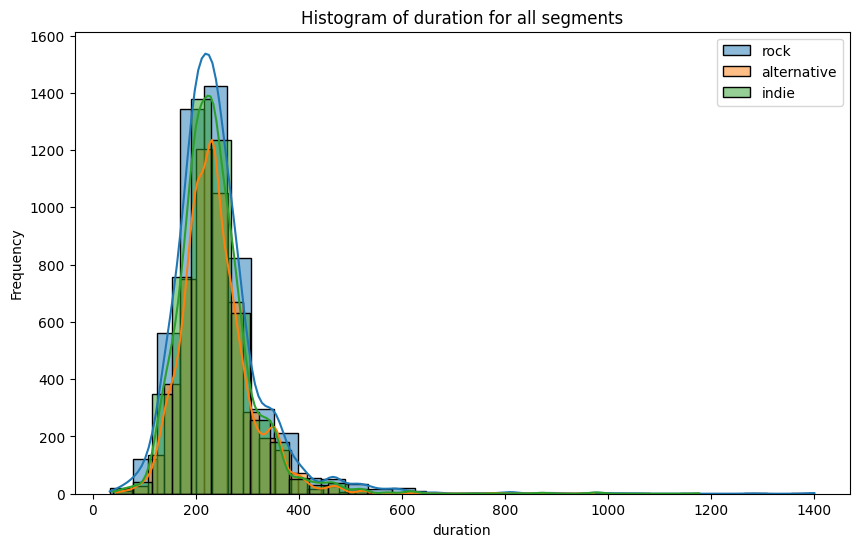

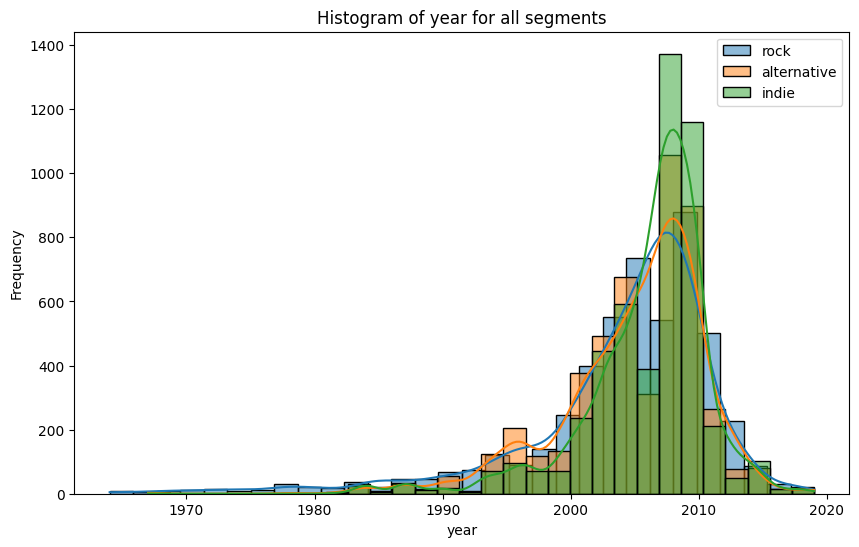

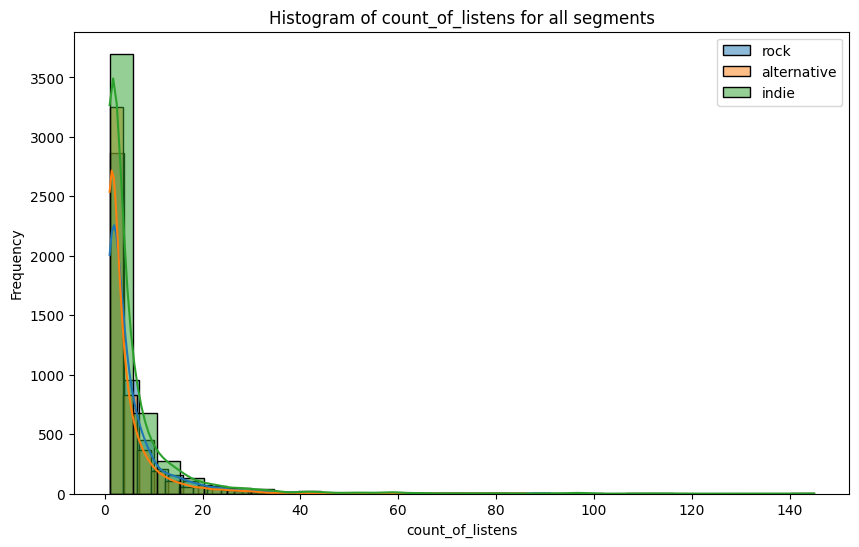

In [86]:
print("\nHistograms:")
for metric, data_dict in segments.items():
    plt.figure(figsize=(10, 6))
    for segment, data in data_dict.items():
        sns.histplot(data, kde=True, label=segment, bins=30)
    plt.title(f"Histogram of {metric} for all segments")
    plt.xlabel(metric)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()



In [89]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, f_oneway

[print(f"Test shapiro segment {segment}: p-value = ", shapiro(segments[metric][segment]).pvalue) for segment in name_segments]
print()
# Если данные нормальны, применяем тест Стьюдента, иначе Манна-Уитни
print("\nT-Test:")
for metric in segments.keys():
    print(f"Metric: {metric}")
    for segment_a, segment_b in pairs_segments:
        if shapiro(segments[metric][segment_a]).pvalue > 0.05 and shapiro(segments[metric][segment_b]).pvalue > 0.05:
            t_stat, t_pvalue = ttest_ind(segments[metric][segment_a], segments[metric][segment_b], equal_var=False)
            print(f"T-test between Segment {segment_a} and {segment_b}: p_value={t_pvalue}")
        else:
            u_stat, u_pvalue = mannwhitneyu(segments[metric][segment_a], segments[metric][segment_b])
            print(f"Mann-Whitney U test between Segment {segment_a} and {segment_b}: p_value={u_pvalue}")
    print()


Test shapiro segment rock: p-value =  2.91003603238827e-76
Test shapiro segment alternative: p-value =  7.570027100210066e-77
Test shapiro segment indie: p-value =  9.1165266763599e-81


T-Test:
Metric: duration
Mann-Whitney U test between Segment rock and alternative: p_value=0.434644849631608
Mann-Whitney U test between Segment rock and indie: p_value=0.3298160834290844
Mann-Whitney U test between Segment alternative and indie: p_value=0.06582690054887408

Metric: year
Mann-Whitney U test between Segment rock and alternative: p_value=0.0006249814648889027
Mann-Whitney U test between Segment rock and indie: p_value=4.50800300257773e-41
Mann-Whitney U test between Segment alternative and indie: p_value=9.798117012750239e-25

Metric: count_of_listens
Mann-Whitney U test between Segment rock and alternative: p_value=4.4358430242170596e-23
Mann-Whitney U test between Segment rock and indie: p_value=4.163677169438508e-13
Mann-Whitney U test between Segment alternative and indie: p_value=0.

In [90]:
print("\nANOVA (Fisher's test):")
for metric in segments.keys():
    print(f"Metric: {metric}")
    f_stat, f_pvalue = f_oneway(*segments[metric].values())
    print(f"p-value={f_pvalue}")
    print()


ANOVA (Fisher's test):
Metric: duration
p-value=0.003444311902007136

Metric: year
p-value=3.0670282401359493e-63

Metric: count_of_listens
p-value=2.048081728275897e-12



**Выводы:**
1. **Нормальность распределения (Shapiro Test):**

Для всех сегментов (rock, alternative, indie) p-значения Shapiro-теста очень низкие (меньше 0.05). Это говорит о том, что распределения метрики duration для всех сегментов не соответствуют нормальному распределению.
В результате для дальнейших сравнений использовались непараметрические тесты.
2. **Тесты Манна-Уитни (Pairwise Comparisons):**

**Метрика duration:**

Все пары сегментов (rock и alternative, rock и indie, alternative и indie) имеют p-значения больше 0.05. Это указывает на отсутствие значимых различий в длительности треков между сегментами.

**Метрика year:**

Все p-значения значительно ниже 0.05, что говорит о существенных различиях в годах между всеми парами сегментов.

**Метрика count_of_listens:**

Для всех пар сегментов p-значения меньше 0.05. Это означает, что число прослушиваний значительно различается между всеми сегментами.

3. **ANOVA (Fisher's Test):**

**Метрика duration:**

p-значение = 0.0034. Это меньше 0.05, что говорит о значимых различиях в длительности треков между сегментами. Однако, для конкретных пар значимых различий не обнаружено (по Манна-Уитни). Возможно, общие различия обусловлены накопленным эффектом между всеми группами.

**Метрика year:**

p-значение = 3.07e-63. Это указывает на очень сильные различия в годах между сегментами, что подтверждается и Манна-Уитни.

**Метрика count_of_listens:**

p-значение = 2.05e-12. Это также указывает на значимые различия в количестве прослушиваний между сегментами, что подтверждается тестами Манна-Уитни.


# Задание 3


In [93]:
fisher_test_results = []
name_row = []
# Попарные сравнения через тест Фишера
print("\nPairwise Fisher's Tests:")
for metric in segments.keys():
    print(f"Metric: {metric}")
    name_row.append(metric)
    fisher_test_results.append('------')
    for seg_a, seg_b in pairs_segments:
        f_stat, f_pvalue = f_oneway(segments[metric][seg_a], segments[metric][seg_b])
        print(f"Fisher's test {seg_a} and {seg_b}: p-value={f_pvalue}")
        fisher_test_results.append(f_pvalue)
        name_row.append(f"{seg_a} and {seg_b}")
    print()


Pairwise Fisher's Tests:
Metric: duration
Fisher's test rock and alternative: p-value=0.00932085409785217
Fisher's test rock and indie: p-value=0.003304451733961117
Fisher's test alternative and indie: p-value=0.5988720350604884

Metric: year
Fisher's test rock and alternative: p-value=1.6046392019609722e-13
Fisher's test rock and indie: p-value=1.0540527860378276e-59
Fisher's test alternative and indie: p-value=1.285599604135861e-25

Metric: count_of_listens
Fisher's test rock and alternative: p-value=8.154943026159851e-14
Fisher's test rock and indie: p-value=0.45348181472299043
Fisher's test alternative and indie: p-value=4.301867619310124e-09



In [99]:
# Если данные нормальны, применяем тест Стьюдента, иначе Манна-Уитни
t_test_results = []
for metric in segments.keys():
    t_test_results.append('------')
    for segment_a, segment_b in pairs_segments:
        t_stat, t_pvalue = ttest_ind(segments[metric][segment_a], segments[metric][segment_b], equal_var=False)
        t_test_results.append(t_pvalue)

In [101]:
results_df = pd.DataFrame({
    'name': [row for row in name_row],
    'T test': [pval for pval in t_test_results],
    'Fisher Test': [pval for pval in fisher_test_results]
})
print("\nComparison Table:")
results_df.head(12)


Comparison Table:


,name,T test,Fisher Test
0,duration,------,------
1,rock and alternative,0.009322,0.009321
2,rock and indie,0.003305,0.003304
3,alternative and indie,0.598872,0.598872
4,year,------,------
5,rock and alternative,0.0,0.0
6,rock and indie,0.0,0.0
7,alternative and indie,0.0,0.0
8,count_of_listens,------,------
9,rock and alternative,0.0,0.0


**Вывод:**
Для двух групп результат теста Фишера совпадает с тестом Стьюдента.

# Задание 4

In [96]:
# Функция для точного доверительного интервала разницы средних
from math import sqrt
from scipy.stats import t
import numpy as np

def mean_diff_ci_t(sample1, sample2, alpha=0.05):
    """T-интервал для разницы средних двух выборок."""
    n1, n2 = len(sample1), len(sample2)
    mean1, mean2 = np.mean(sample1), np.mean(sample2)
    s1, s2 = np.std(sample1, ddof=1), np.std(sample2, ddof=1)

    mean_diff = mean1 - mean2
    se_diff = sqrt((s1 ** 2 / n1) + (s2 ** 2 / n2))
    df = min(n1 - 1, n2 - 1)  # Степени свободы

    t_val = t.ppf(1 - alpha / 2, df)
    half_width = t_val * se_diff

    return (mean_diff - half_width, mean_diff + half_width)

# Функция для bootstrap доверительного интервала разницы средних
def bootstrap_mean_diff_ci(sample1, sample2, alpha=0.05, num_bootstrap=1000):
    """Bootstrap доверительный интервал для разницы средних двух выборок."""
    boot_diffs = []
    for _ in range(num_bootstrap):
        s1 = np.random.choice(sample1, size=len(sample1), replace=True)
        s2 = np.random.choice(sample2, size=len(sample2), replace=True)
        boot_diffs.append(np.mean(s1) - np.mean(s2))
    lower = np.percentile(boot_diffs, 100 * (alpha / 2))
    upper = np.percentile(boot_diffs, 100 * (1 - alpha / 2))
    return lower, upper


In [97]:
# Расчет доверительных интервалов разницы средних для пар сегментов
print("\nConfidence Intervals for Mean Differences:")
for metric in segments.keys():
    print(f"Metric: {metric}")
    for seg_a, seg_b in pairs_segments:
        ci_t = mean_diff_ci_t(segments[metric][seg_a], segments[metric][seg_b])
        ci_bootstrap = bootstrap_mean_diff_ci(segments[metric][seg_a], segments[metric][seg_b])
        print(f"{seg_a} vs {seg_b}: "f"T-Based 95% CI = {ci_t} Bootstrap 95% CI = {ci_bootstrap}")
    print()


Confidence Intervals for Mean Differences:
Metric: duration
rock vs alternative: T-Based 95% CI = (1.0054640957517118, 7.16413590424829) Bootstrap 95% CI = (0.8542500000000182, 7.063445000000022)
rock vs indie: T-Based 95% CI = (1.6059542760084433, 8.043245723991507) Bootstrap 95% CI = (1.753664999999991, 8.104734999999998)
alternative vs indie: T-Based 95% CI = (-2.017276117602554, 3.4968761176025023) Bootstrap 95% CI = (-2.127580000000003, 3.494180000000007)

Metric: year
rock vs alternative: T-Based 95% CI = (-1.267363790828464, -0.7358362091716422) Bootstrap 95% CI = (-1.2516900000000533, -0.7492599999999244)
rock vs indie: T-Based 95% CI = (-2.3742377773384566, -1.867362222661833) Bootstrap 95% CI = (-2.374599999999873, -1.8553749999998674)
alternative vs indie: T-Based 95% CI = (-1.3283361058531535, -0.9100638941470298) Bootstrap 95% CI = (-1.3246149999999204, -0.9171850000000916)

Metric: count_of_listens
rock vs alternative: T-Based 95% CI = (0.7599891093199953, 1.300010890680

**Вывод:**
Все интервалы(T-Based и Bootstrap)  соотвествуют результатам теста Стьюдента:

Если доверительный интервал содержит ноль, то тест Стьюдента показывает незначимые различия (p > 0.05)(Примеры: alternative и indie по метрике duration и rock vs indie по метрике count_of_listens).

Если доверительный интервал не содержит ноль, то тест Стьюдента показывает значимые различия (p < 0.05).

# Задание 5

Можно, например, **Перестановочный критерий**, для него могли не обрезать выборки, он работает для выборок разного размера.

In [103]:
from scipy.stats import permutation_test

perm_result = permutation_test(
    [segments['duration']['indie'], segments['duration']['alternative']],
    statistic=lambda x, y: np.mean(x) - np.mean(y),
    alternative='two-sided',
    n_resamples=10000
)
print(f"Permutation Test: p-value={perm_result.pvalue}")

Permutation Test: p-value=0.6143385661433857
